In [13]:
from langchain_ollama import ChatOllama, OllamaEmbeddings
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_chroma import Chroma
from langgraph.graph import START, END, StateGraph
from typing import TypedDict, Annotated
from langchain.tools import tool
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.graph.message import add_messages
from langchain_core.messages import BaseMessage, HumanMessage

In [3]:
llm = ChatOllama(model = "llama3.2")

In [4]:
# RAG Pipeine
#1. Documnet loaders
loader = PyPDFLoader("intro-to-ml.pdf")
docs = loader.load()




In [5]:
len(docs)

234

In [6]:
#2. Text Splitters
text_splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=200)
chunks = text_splitter.split_documents(docs)
len(chunks)

566

In [7]:
#3. Embeddings
embeddings = OllamaEmbeddings(model = "embeddinggemma")
vector_store = Chroma.from_documents(chunks, embeddings)

In [8]:
#4. retrriever
retriever = vector_store.as_retriever(search_type = "similarity", search_kwargs = {"k": 4})

In [15]:
retriever.invoke("What is a decision tree?")

[Document(id='e060bab2-2aec-4823-8473-4bd3afaba2bf', metadata={'creator': 'LaTeX with hyperref package', 'author': 'AlexJ.SmolaandVishyS.V.N.Vishwanathan', 'source': 'intro-to-ml.pdf', 'creationdate': '2010-10-01T15:47:05-07:00', 'ptex.fullbanner': 'This is pdfTeX, Version 3.1415926-1.40.10-2.2 (TeX Live/MacPorts 2009_6) kpathsea version 5.0.0', 'page': 0, 'page_label': 'i', 'title': 'AnIntroductiontoMachineLearning', 'producer': 'pdfTeX-1.40.10', 'subject': '', 'total_pages': 234, 'moddate': '2010-10-01T15:47:05-07:00', 'keywords': '', 'trapped': '/False'}, page_content='INTRODUCTION TO MACHINE LEARNING'),
 Document(id='1eda05cf-b292-4f25-b939-43048da3da6f', metadata={'author': 'AlexJ.SmolaandVishyS.V.N.Vishwanathan', 'keywords': '', 'total_pages': 234, 'title': 'AnIntroductiontoMachineLearning', 'subject': '', 'creator': 'LaTeX with hyperref package', 'page': 16, 'page_label': '9', 'ptex.fullbanner': 'This is pdfTeX, Version 3.1415926-1.40.10-2.2 (TeX Live/MacPorts 2009_6) kpathsea v

In [10]:
@tool
def rag_tool(query):
    """
    Retrieve relevant information from the pdf document.
    Use this tool when the user asks factual / conceptual questions.
    that might be answered from this stored documents"""
    result = retriever.invoke(query)

    context = [docs.page_content for docs in result]
    metadata = [docs.metadata for docs in result]

    return {
        'query': query,
        'context': context,
        'metadata': metadata
    }


In [17]:
tools = [rag_tool]
llm_with_tool = llm.bind_tools(tools)

In [19]:
# Build state
class RAG_STATE(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

In [21]:
#Writing Functions for nodes

def chat_node(state: RAG_STATE):
    messages = state["messages"]
    response = llm_with_tool.invoke(messages)
    return {"messages": [response]}

tool_node = ToolNode(tools)

In [24]:
#graph

graph = StateGraph(RAG_STATE)

graph.add_node("chat", chat_node)
graph.add_node("tools", tool_node)

graph.add_edge(START, "chat")
graph.add_conditional_edges("chat", tools_condition)
graph.add_edge("tools", "chat")

workflow = graph.compile()

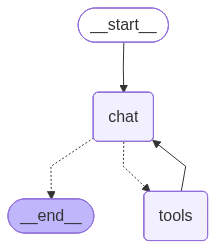

In [25]:
workflow

In [26]:
initial_state = RAG_STATE(messages = [HumanMessage(content = "What is a decision tree?")])
final_state = workflow.invoke(initial_state)

In [31]:
final_state['messages'][-1].content

'A decision tree is a graphical representation of a decision-making process, where each node represents a choice or action, and the branches represent the possible outcomes. It\'s a type of supervised learning algorithm used in machine learning, particularly in classification problems.\n\nThe basic idea behind a decision tree is to create a tree-like model that splits the data into smaller subsets based on certain conditions or features. The goal is to find the best split that separates the positive and negative classes (or targets) in the dataset.\n\nHere\'s how it works:\n\n1. **Root node**: The decision tree starts with a root node, which represents the overall problem or classification task.\n2. **Child nodes**: From each root node, we create child nodes based on certain conditions or features in the data. For example, if the feature is "age," one child node might represent children (under 18) and another child node might represent adults (18+).\n3. **Leaf nodes**: As we split the 

Failed to send compressed multipart ingest: Connection error caused failure to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. Please confirm your internet connection. ConnectionError(MaxRetryError('HTTPSConnectionPool(host=\'api.smith.langchain.com\', port=443): Max retries exceeded with url: /runs/multipart (Caused by NameResolutionError("HTTPSConnection(host=\'api.smith.langchain.com\', port=443): Failed to resolve \'api.smith.langchain.com\' ([Errno 11001] getaddrinfo failed)"))'))
Content-Length: 2879
API Key: lsv2_********************************************17trace=019d24e2-9d8e-7083-85ec-a08383eb6a44,id=019d24e4-3ff8-7a60-ace4-c861284076de; trace=019d24e2-9d8e-7083-85ec-a08383eb6a44,id=019d24e4-3ff8-7a60-ace4-c861284076de; trace=019d24e2-9d8e-7083-85ec-a08383eb6a44,id=019d24e3-2041-7bd0-a079-a2224cfc6e6a; trace=019d24e2-9d8e-7083-85ec-a08383eb6a44,id=019d24e2-9d8e-7083-85ec-a08383eb6a44
